# asymptotics — Coupled ODE Systems

`ODESystem` applies regular perturbation to **coupled systems of ODEs**.

## The key insight

For a system like:
$$u' + u + \varepsilon v = 0, \qquad v' + 2v + \varepsilon u^2 = 0$$

At each order $k$, the equations for $u_k(t)$ and $v_k(t)$ are **decoupled** — each depends only on lower-order solutions. So we solve $N$ independent ODEs at every order, one per variable.

The interface is identical to `ODE` — just provide multiple equations and dependents:

```python
from asymptotics import ODESystem

sys = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"],
)
sol = sys.expand_regular(order=2)
sol.show()
```

In [1]:
# compare_numeric is built into every hierarchy — no helper needed!
# sol.compare_numeric(eps=0.1, problem=sys) works directly.
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import *
from IPython.display import display, Math
from asymptotics import ODESystem

t_sym = symbols('t')

---
## Example 1 — Weakly coupled decay equations

$$u' + u + \varepsilon v = 0, \qquad u(0) = 1$$
$$v' + 2v + \varepsilon u^2 = 0, \qquad v(0) = 1$$

At $\mathcal{O}(1)$: decoupled exponential decays $u_0 = e^{-t}$, $v_0 = e^{-2t}$.

At $\mathcal{O}(\varepsilon)$: coupling enters — $v_0$ drives $u_1$, and $u_0^2$ drives $v_1$.

In [2]:
sys1 = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"],
)
sol1 = sys1.expand_regular(order=2)
sol1.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

/Users/tsaad_1/Library/CloudStorage/GoogleDrive-tony.saad@chemeng.utah.edu/My Drive/Research/asymptotics toolkit/Asymptotics Toolkit_git/asymptotics/methods/regular_ode_system.py:180: UserWarning: 't_range' is not a valid parameter — use 'plot_range' instead.
  return compare_numeric(self, eps, params=params, **kwargs)


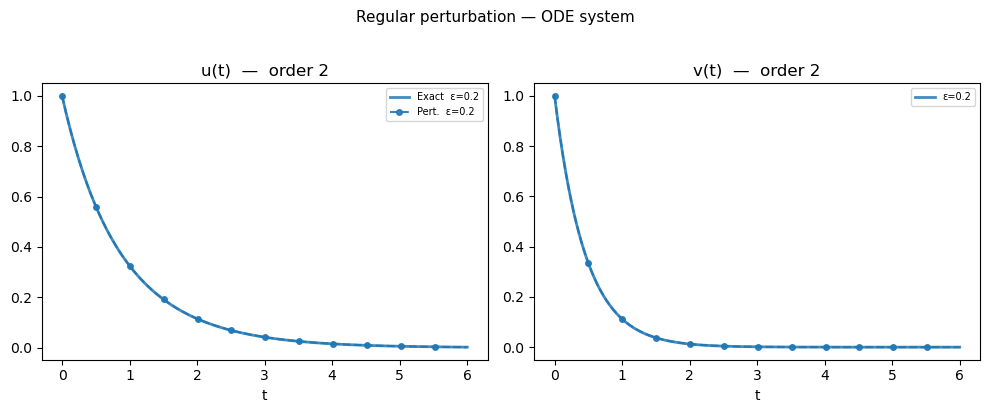

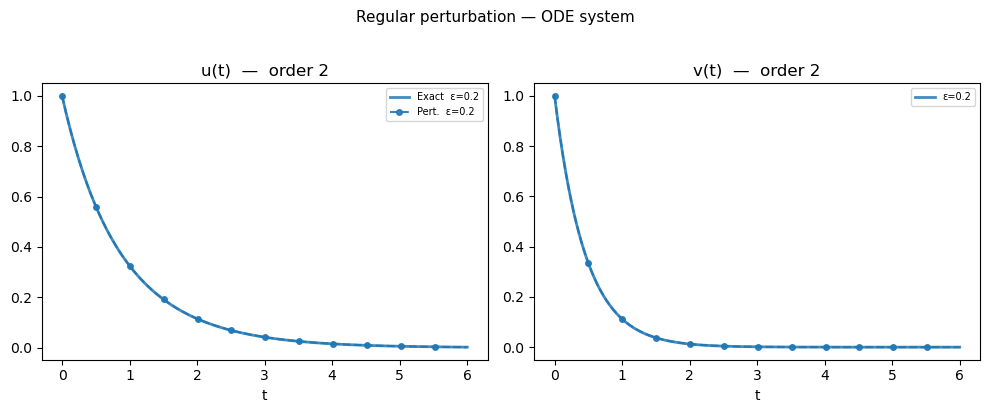

In [3]:
eps_val = 0.2
result  = sol1.compare_numeric(eps=eps_val, problem=sys1, t_range=[0, 6])
result['fig']

---
## Example 2 — Cross-coupling: u drives v, v drives u

$$u' + u + \varepsilon v^2 = 0, \qquad u(0) = 1$$
$$v' + 2v + \varepsilon u = 0, \qquad v(0) = 0$$

With $v(0) = 0$, the O(1) solution $v_0 = 0$ means $u$ is unaffected at O(ε) (since $v_0^2 = 0$). The first non-trivial coupling appears at O(ε²).

In [16]:
sys2 = ODESystem(
    equations   = ["u' + u + eps*v**2", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 0.1", "v(0) = 0"],
)
sol2 = sys2.expand_regular(order=2)
sol2.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

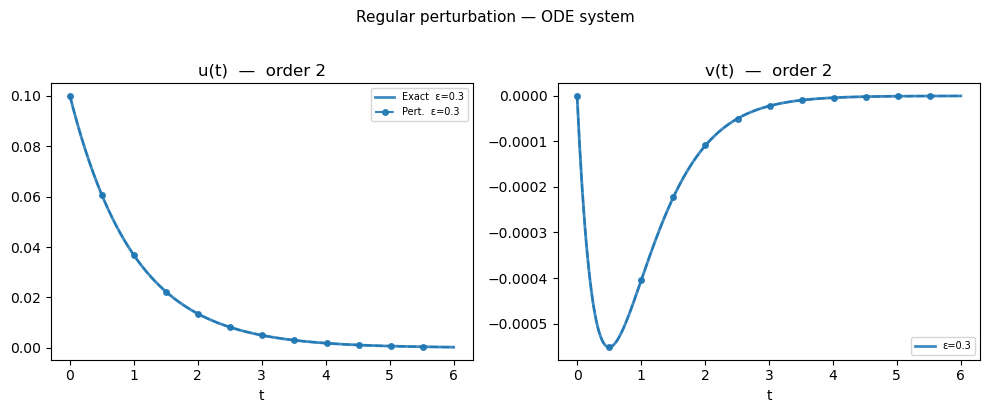

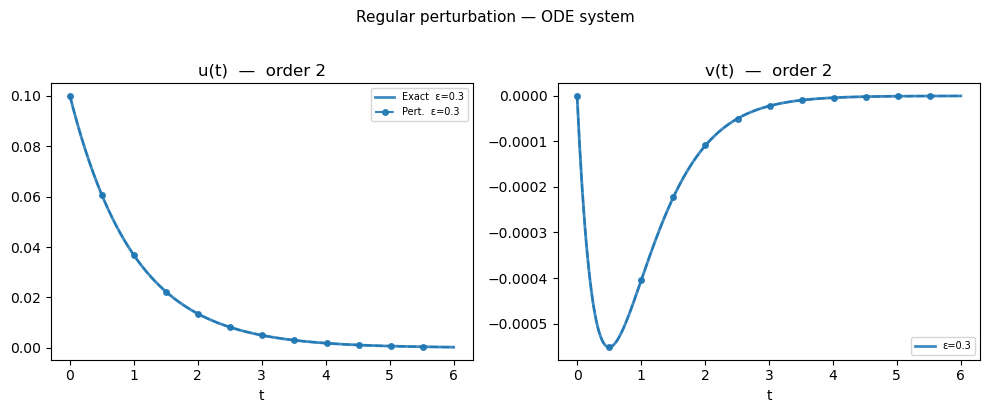

In [17]:
eps_val = 0.3
result  = sol2.compare_numeric(eps=eps_val, problem=sys2, t_range=[0, 6])
result['fig']

---
## Example 3 — Three-equation cascade

$$u' + u + \varepsilon v = 0, \qquad u(0) = 1$$
$$v' + 2v + \varepsilon u^2 = 0, \qquad v(0) = 1$$
$$w' + w + \varepsilon(u + v) = 0, \qquad w(0) = 0$$

The third variable $w$ is driven by both $u$ and $v$. At O(1): $w_0 = 0$. At O(ε): $w$ picks up contributions from $u_0$ and $v_0$.

In [8]:
sys3 = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2", "w' + w + eps*(u+v)"],
    dependents  = ["u", "v", "w"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1", "w(0) = 0"],
)
sol3 = sys3.expand_regular(order=2)
sol3.show()

RuntimeError: 

  Could not solve order-2 ODE for 'w':
  Eq(t*sinh(2*t) - t*cosh(2*t) + w_2(t) + sinh(t) - sinh(2*t) - cosh(t) + cosh(2*t) + Derivative(w_2(t), t), 0)
  Error: Could not solve `t*sinh(2*t) - t*cosh(2*t) + w_2(t) + sinh(t) - sinh(2*t) - cosh(t) + cosh(2*t) + Derivative(w_2(t), t)` using the method of undetermined coefficients (unable to solve for coefficients).


  max error u: 2.11e-03
  max error v: 2.14e-03
  max error w: 5.47e-03


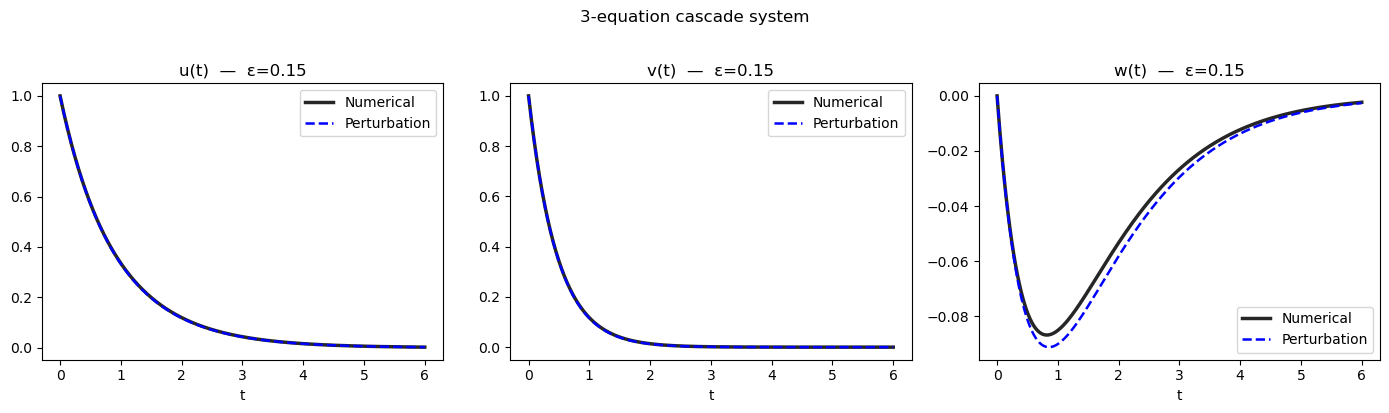

In [9]:
eps_val = 0.15
t_vals  = np.linspace(0, 6, 400)
eps_sym = sol3.small_param

def rhs3(t, y):
    u, v, w = y
    return [-u - eps_val*v, -2*v - eps_val*u**2, -w - eps_val*(u+v)]

num3 = solve_ivp(rhs3, [0, 6], [1.0, 1.0, 0.0], dense_output=True, rtol=1e-10)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var, i in zip(axes, ['u', 'v', 'w'], range(3)):
    fn = lambdify(t_sym, sol3[var].composite.subs(eps_sym, eps_val), 'numpy')
    u_p = np.real(np.array([complex(fn(ti)) for ti in t_vals]))
    u_n = num3.sol(t_vals)[i]
    ax.plot(t_vals, u_n, 'k-',  lw=2.5, label='Numerical', alpha=0.85)
    ax.plot(t_vals, u_p, 'b--', lw=1.8, label='Perturbation')
    ax.set_title(f'{var}(t)  —  ε={eps_val}')
    ax.set_xlabel('t'); ax.legend()
    print(f'  max error {var}: {np.max(np.abs(u_p - u_n)):.2e}')

plt.suptitle('3-equation cascade system', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Example 4 — Predator-prey (Lotka-Volterra type)

$$u' - u + \varepsilon u v = 0, \qquad u(0) = 1$$
$$v' + 2v - \varepsilon u v = 0, \qquad v(0) = 1$$

At O(1): $u_0 = e^{t}$ (prey grows), $v_0 = e^{-2t}$ (predators decay without prey).

The coupling $\varepsilon uv$ at O(ε) captures the predator-prey interaction.

In [12]:
sys4 = ODESystem(
    equations   = ["u' - u + eps*u*v", "v' + 2*v - eps*u*v"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"],
)
sol4 = sys4.expand_regular(order=2)
sol4.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

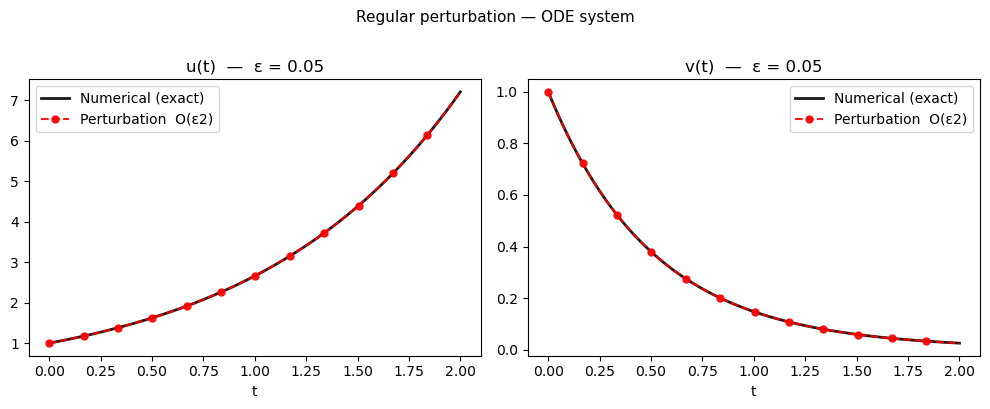

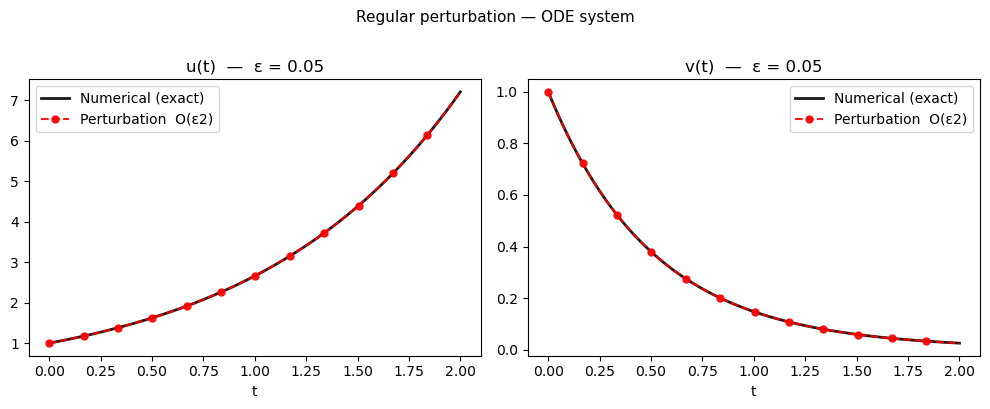

In [13]:
eps_val = 0.05
result  = sol4.compare_numeric(eps=eps_val, problem=sys4, t_range=[0, 2])
result['fig']

---
## API quick reference

```python
from asymptotics import ODESystem

sys = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],          # one per equation
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"],  # flat list, auto-matched
)

sol = sys.expand_regular(order=2)

# Display
sol.show()                          # full hierarchy (LaTeX in Jupyter)

# Access by variable name
sol["u"].composite                  # full expansion for u
sol["v"].composite                  # full expansion for v
sol["u"][k].particular_solution    # u_k(t) at order k
sol["v"][k].ode                    # ODE for v_k at order k

# Works for N equations
sys3 = ODESystem(
    equations  = ["u' + u + eps*v", "v' + 2*v + eps*u**2", "w' + w + eps*(u+v)"],
    dependents = ["u", "v", "w"],
    ...
)
```

**Condition syntax** — same as `ODE`, flat list auto-matched by variable name:
```python
conditions = ["u(0) = 1", "v(0) = 0"]          # 1st-order system
conditions = ["u(0) = 1", "u'(0) = 0",          # 2nd-order u
              "v(0) = 0"]                        # 1st-order v
```